# ForgeAI 판단 일관성 검증 — Colab 실행 환경

**목적**: 멀티에이전트 파이프라인의 판단 일관성을 30-run(5회 × 6 stratum) 으로 측정  
**환경**: Google Colab Pro (GPU: T4/A100)  
**LLM**: Ollama + qwen2.5:7b (GPU 가속)  
**임베딩**: nomic-embed-text (Ollama)

## 실행 순서
1. GPU 런타임 설정 → `런타임 > 런타임 유형 변경 > T4 GPU`
2. Cell 1 ~ 7 순서대로 실행
3. Cell 7 완료 후 리포트·차트 자동 다운로드


## Cell 1 — GPU 확인 및 Ollama 설치

In [1]:
import subprocess, os, time, shutil, platform

# GPU 확인
r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                   capture_output=True, text=True)
print('GPU:', r.stdout.strip() or '없음 (CPU 실행 — 속도 느림)')


def ensure_zstd():
    if shutil.which('zstd'):
        return True
    print('\napt-get으로 zstd 설치 시도 중...')
    r = subprocess.run(
        'apt-get update -qq && apt-get install -y -qq zstd',
        shell=True, capture_output=True, text=True
    )
    if r.returncode != 0:
        print(f'apt-get 실패 (returncode={r.returncode}):')
        print((r.stderr or r.stdout)[-500:])
    return shutil.which('zstd') is not None


INSTALL_DIR = None  # 수동 설치 시 사용한 경로 (bin/ollama 탐색용)

if ensure_zstd():
    print('\nOllama 설치 중 (install.sh)...')
    install = subprocess.run(
        'curl -fsSL https://ollama.com/install.sh | sh',
        shell=True, capture_output=True, text=True
    )
    print(install.stdout[-300:] if install.stdout else '')
    if install.returncode != 0:
        print('설치 오류:', install.stderr[-300:])
else:
    # apt-get으로 zstd를 설치할 수 없는 환경(권한/락/네트워크 제한 등) —
    # install.sh와 동일한 다운로드 URL을 Python의 zstandard 라이브러리로 직접 해제
    print('\nzstd 설치 실패 — Python 기반 수동 설치로 대체합니다.')
    subprocess.run(['pip', 'install', '-q', 'zstandard'], check=True)
    import urllib.request, tarfile, io
    import zstandard

    arch = {'x86_64': 'amd64', 'aarch64': 'arm64', 'arm64': 'arm64'}.get(platform.machine(), 'amd64')
    url = f'https://ollama.com/download/ollama-linux-{arch}.tar.zst'

    INSTALL_DIR = '/usr/local' if os.access('/usr/local', os.W_OK) else '/content/ollama'
    os.makedirs(INSTALL_DIR, exist_ok=True)

    print(f'다운로드: {url}')
    with urllib.request.urlopen(url) as resp:
        raw = resp.read()

    print(f'압축 해제 중 → {INSTALL_DIR}')
    dctx = zstandard.ZstdDecompressor()
    with dctx.stream_reader(io.BytesIO(raw)) as reader:
        with tarfile.open(fileobj=reader, mode='r|') as tar:
            tar.extractall(INSTALL_DIR)
    print('수동 설치 완료')

# 실제 설치 경로 탐색
OLLAMA_BIN = None
candidates = ['/usr/local/bin/ollama', '/usr/bin/ollama', '/bin/ollama']
if INSTALL_DIR:
    candidates.insert(0, os.path.join(INSTALL_DIR, 'bin', 'ollama'))
for candidate in candidates:
    if os.path.isfile(candidate):
        OLLAMA_BIN = candidate
        break
if not OLLAMA_BIN:
    find = subprocess.run('find / -name ollama -type f 2>/dev/null | head -3',
                          shell=True, capture_output=True, text=True)
    paths = find.stdout.strip().splitlines()
    OLLAMA_BIN = paths[0] if paths else None
if not OLLAMA_BIN:
    raise RuntimeError('Ollama 바이너리를 찾을 수 없습니다.')

print(f'Ollama 경로: {OLLAMA_BIN}')
os.environ['PATH'] = os.path.dirname(OLLAMA_BIN) + ':' + os.environ.get('PATH', '')

# 서버 시작
subprocess.Popen([OLLAMA_BIN, 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)

r = subprocess.run(['curl', '-s', 'http://localhost:11434/api/tags'], capture_output=True, text=True)
print('Ollama 서버 상태:', 'OK' if r.returncode == 0 else 'FAILED')


GPU: Tesla T4, 15360 MiB

Ollama 설치 중 (install.sh)...

Ollama 경로: /usr/local/bin/ollama
Ollama 서버 상태: OK


## Cell 2 — 모델 다운로드 (5~10분)

In [2]:
import subprocess, time, os

# Ollama 바이너리 경로 복구
OLLAMA_BIN = next(
    (c for c in ['/usr/local/bin/ollama', '/usr/bin/ollama', '/bin/ollama'] if os.path.isfile(c)),
    None
)
if not OLLAMA_BIN:
    raise RuntimeError('Ollama 바이너리를 찾을 수 없습니다. Cell 1을 먼저 실행하세요.')

models = [
    ('qwen2.5:7b',       'LLM (채팅 에이전트)'),
    ('nomic-embed-text', '임베딩 (ChromaDB 벡터 검색)'),
]

for model, desc in models:
    print(f'  다운로드 중: {model} ({desc})...')
    t0 = time.time()
    r = subprocess.run([OLLAMA_BIN, 'pull', model], capture_output=True, text=True)
    elapsed = time.time() - t0
    print(f'  {"✓" if r.returncode == 0 else "✗"} {model} ({elapsed:.0f}초)')
    if r.returncode != 0:
        print('    오류:', r.stderr[-300:])

r = subprocess.run([OLLAMA_BIN, 'list'], capture_output=True, text=True)
print('\n설치된 모델:\n', r.stdout)


  다운로드 중: qwen2.5:7b (LLM (채팅 에이전트))...
  ✓ qwen2.5:7b (1초)
  다운로드 중: nomic-embed-text (임베딩 (ChromaDB 벡터 검색))...
  ✓ nomic-embed-text (1초)

설치된 모델:
 NAME                       ID              SIZE      MODIFIED               
nomic-embed-text:latest    0a109f422b47    274 MB    Less than a second ago    
qwen2.5:7b                 845dbda0ea48    4.7 GB    1 second ago              



## Cell 3 — 저장소 클론 및 의존성 설치

In [3]:
import os, subprocess

REPO_URL = 'https://github.com/enjoylonelines/ForgeAI.git'
REPO_DIR = '/content/ForgeAI'
BRANCH   = 'feat/p0-evidence-scripts'  # save_distribution_chart 등이 아직 main에 병합되지 않음

if not os.path.exists(REPO_DIR):
    print('저장소 클론 중...')
    subprocess.run(['git', 'clone', '-b', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    print('이미 존재 — fetch 후 브랜치 정렬')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', f'origin/{BRANCH}'], check=True)

os.chdir(REPO_DIR)
print(f'작업 디렉터리: {os.getcwd()}')
r = subprocess.run(['git', 'rev-parse', '--abbrev-ref', 'HEAD'], capture_output=True, text=True)
print(f'브랜치: {r.stdout.strip()}')

print('\nPython 패키지 설치 중...')
pkgs = [
    'langchain>=0.3.0', 'langchain-ollama>=0.2.0', 'langchain-chroma>=0.1.0',
    'langgraph>=0.2.0', 'chromadb>=0.5.0', 'pydantic>=2.7.0',
    'pandas>=2.2.0', 'ucimlrepo>=0.0.7', 'langfuse>=2.0.0',
    'pypdf>=4.2.0', 'python-dotenv>=1.0.1',
    'xgboost>=2.0.0', 'scikit-learn>=1.4.0',
    'matplotlib>=3.8.0', 'numpy>=1.26.0', 'nest_asyncio',
]
subprocess.run(['pip', 'install', '-q'] + pkgs, check=True)
print('패키지 설치 완료 ✓')


이미 존재 — fetch 후 브랜치 정렬
작업 디렉터리: /content/ForgeAI
브랜치: feat/p0-evidence-scripts

Python 패키지 설치 중...
패키지 설치 완료 ✓


## Cell 4 — 환경 변수 설정

In [4]:
import os

os.environ.update({
    'OLLAMA_BASE_URL':       'http://localhost:11434',
    'OLLAMA_CHAT_MODEL':     'qwen2.5:7b',
    'OLLAMA_EMBED_MODEL':    'nomic-embed-text',
    'OLLAMA_TIMEOUT_SECONDS':'300',
    'OLLAMA_NUM_CTX':        '2048',
    'OLLAMA_NUM_PREDICT':    '512',
    'CHROMA_PERSIST_DIR':    '/content/ForgeAI/data/chroma',
    'DECISION_LOG_PATH':     '/content/ForgeAI/logs/decisions.jsonl',
    'LANGFUSE_ENABLED':      'false',
    'LOG_LEVEL':             'WARNING',
})

os.makedirs('/content/ForgeAI/logs', exist_ok=True)
os.makedirs('/content/ForgeAI/docs', exist_ok=True)

r = subprocess.run(['curl', '-s', 'http://localhost:11434/api/tags'], capture_output=True, text=True)
print('Ollama 연결:', 'OK' if r.returncode == 0 else 'FAILED')
print('환경 설정 완료 ✓')


Ollama 연결: OK
환경 설정 완료 ✓


## Cell 5 — SOP 문서 인덱싱 (ChromaDB 구축)

In [5]:
import sys, asyncio, shutil
from pathlib import Path
sys.path.insert(0, '/content/ForgeAI')

import nest_asyncio
nest_asyncio.apply()

from core.config import get_settings
get_settings.cache_clear()

# rag.chroma_client의 전역 클라이언트 캐시를 리셋 —
# 캐시된 상태로 디렉터리를 rmtree하면 존재하지 않는 세그먼트를 참조해 InternalError 발생
import rag.chroma_client as chroma_client_module
chroma_client_module._client = None


async def reindex():
    from rag.ingestion import ingest_document
    sop_dir   = Path('/content/ForgeAI/data/sop_docs')
    chroma_dir = Path('/content/ForgeAI/data/chroma')
    if chroma_dir.exists():
        shutil.rmtree(chroma_dir)

    files = sorted(sop_dir.glob('*.md'))
    print(f'SOP 문서 {len(files)}건 인덱싱 중...')
    last = None
    for f in files:
        last = await ingest_document(
            file_bytes=f.read_bytes(),
            filename=f.name,
            content_type='text/markdown',
        )
        print(f'  ✓ {f.name}  ({last.chunk_count} chunks)')
    print(f'\n인덱싱 완료 — 컬렉션 총 청크: {last.collection_total if last else 0}')

asyncio.run(reindex())


SOP 문서 5건 인덱싱 중...
  ✓ SOP-MNT-001-tool-wear-failure.md  (4 chunks)
  ✓ SOP-MNT-002-heat-dissipation-failure.md  (4 chunks)
  ✓ SOP-MNT-003-power-failure.md  (3 chunks)
  ✓ SOP-MNT-004-overstrain-failure.md  (3 chunks)
  ✓ SOP-MNT-005-random-failure.md  (4 chunks)

인덱싱 완료 — 컬렉션 총 청크: 18


## Cell 6 — 30-run 판단 일관성 검증 실행

> **예상 소요**: T4 GPU 기준 약 30~60분  
> **출력물**: `docs/consistency_report.md`, `docs/consistency_distribution.png`


In [6]:
import sys, asyncio, time
from pathlib import Path
sys.path.insert(0, '/content/ForgeAI')

import nest_asyncio
nest_asyncio.apply()

from core.config import get_settings
get_settings.cache_clear()
from core import langchain_client
langchain_client.get_chat_llm.cache_clear()
langchain_client.get_embeddings.cache_clear()

from scripts.consistency_protocol import (
    load_stratified_samples, run_once,
    build_report, save_distribution_chart,
    consistency_rate, first_divergence_stage,
)
from pipeline.forge_pipeline import ForgePipeline

N_RUNS    = 5
N_SAMPLES = 1
TARGET    = 0.99
OUT_MD    = Path('/content/ForgeAI/docs/consistency_report.md')
OUT_PNG   = Path('/content/ForgeAI/docs/consistency_distribution.png')

print(f'층화 샘플 로드 중 (stratum당 {N_SAMPLES}개)...')
samples = load_stratified_samples(n_per_stratum=N_SAMPLES)
print(f'샘플 {len(samples)}건 → {N_RUNS}회 × {len(samples)}건 = {N_RUNS * len(samples)}회 실행\n')

async def run_all():
    pipeline = ForgePipeline()
    all_results = []
    t_total = time.monotonic()

    for idx, (stratum, log) in enumerate(samples, 1):
        print(f'[{idx:02d}/{len(samples)}] {stratum} {log.equipment_id} × {N_RUNS}회 ...', end=' ', flush=True)
        t0 = time.monotonic()
        runs = [await run_once(pipeline, log) for _ in range(N_RUNS)]

        a_vals  = [r['has_anomaly']    for r in runs]
        rc_vals = [r['recommendation'] for r in runs if r['recommendation'] is not None]
        ro_vals = [r['route']          for r in runs if r['route']          is not None]
        gs_vals = [r['grounding_score'] for r in runs if r['grounding_score'] is not None]

        result = {
            'stratum': stratum, 'equipment_id': log.equipment_id,
            'runs': runs, 'runs_rec': rc_vals, 'runs_route': ro_vals,
            'anomaly_consistency':  consistency_rate(a_vals),
            'rec_consistency':      consistency_rate(rc_vals) if rc_vals else None,
            'route_consistency':    consistency_rate(ro_vals) if ro_vals else None,
            'grounding_scores': gs_vals,
            'divergence_stage': first_divergence_stage([r['stages'] for r in runs]),
        }
        all_results.append(result)

        elapsed = time.monotonic() - t0
        fmt = lambda v: f'{v*100:.0f}%' if v is not None else 'N/A'
        measurable = [v for v in [result['anomaly_consistency'], result['rec_consistency'], result['route_consistency']] if v is not None]
        status = '✅' if (measurable and min(measurable) >= TARGET) else '❌'
        print(f"{status} anomaly={fmt(result['anomaly_consistency'])} rec={fmt(result['rec_consistency'])} route={fmt(result['route_consistency'])} ({elapsed:.0f}s)")

    elapsed_total = time.monotonic() - t_total
    report = build_report(all_results, N_RUNS, elapsed_total, TARGET)
    print('\n' + '='*60 + '\n' + report)

    OUT_MD.write_text(report, encoding='utf-8')
    print(f'리포트 저장: {OUT_MD}')
    save_distribution_chart(all_results, OUT_PNG)
    return all_results

results = asyncio.run(run_all())


층화 샘플 로드 중 (stratum당 1개)...
샘플 6건 → 5회 × 6건 = 30회 실행

[01/6] TWF L47257 × 5회 ... {"timestamp": "2026-07-16T06:53:20.525636+00:00", "level": "WARNING", "name": "pipeline.forge_pipeline", "event": "routing_bridge_dry_run_failed", "correlation_id": "cp-ef9944f4", "error": "C++ control adapter not found at build/control_adapter. Run ./scripts/build_control_adapter.sh first."}
{"timestamp": "2026-07-16T06:54:04.450436+00:00", "level": "WARNING", "name": "pipeline.forge_pipeline", "event": "routing_bridge_dry_run_failed", "correlation_id": "cp-74e62c34", "error": "C++ control adapter not found at build/control_adapter. Run ./scripts/build_control_adapter.sh first."}
{"timestamp": "2026-07-16T06:55:05.165985+00:00", "level": "WARNING", "name": "pipeline.forge_pipeline", "event": "routing_bridge_dry_run_failed", "correlation_id": "cp-3c1a0fc5", "error": "C++ control adapter not found at build/control_adapter. Run ./scripts/build_control_adapter.sh first."}
{"timestamp": "2026-07-16T06:56:06.06

/content/ForgeAI/scripts/consistency_protocol.py:381: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/ForgeAI/scripts/consistency_protocol.py:381: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/ForgeAI/scripts/consistency_protocol.py:381: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/ForgeAI/scripts/consistency_protocol.py:381: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/ForgeAI/scripts/consistency_protocol.py:381: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/ForgeAI/scripts/consistency_protocol.py:381: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/ForgeAI/scripts/consistenc

차트 저장: /content/ForgeAI/docs/consistency_distribution.png


## Cell 7 — 결과 다운로드

판정 분포 차트:


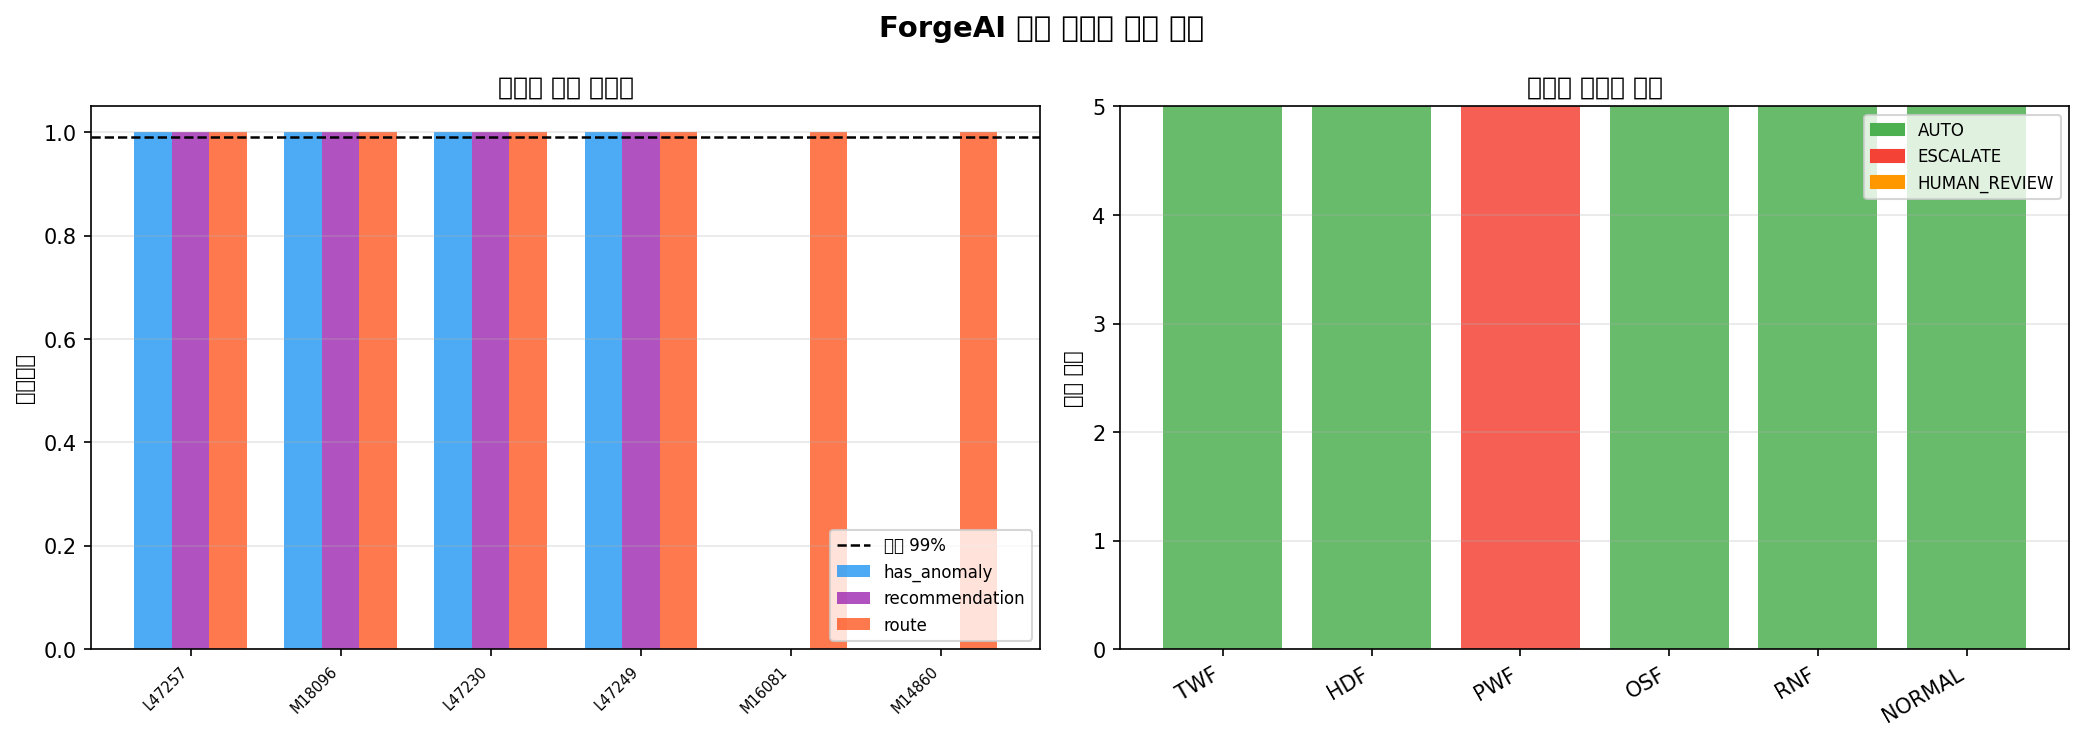

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드: consistency_report.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

다운로드: consistency_distribution.png


In [7]:
# Google Drive 마운트
from google.colab import drive, files
from IPython.display import Image, display
import shutil
from pathlib import Path

drive.mount('/gdrive')

OUT_MD  = Path('/content/ForgeAI/docs/consistency_report.md')
OUT_PNG = Path('/content/ForgeAI/docs/consistency_distribution.png')
DRIVE_DIR = Path('/gdrive/MyDrive/ForgeAI_results')
DRIVE_DIR.mkdir(exist_ok=True)

# Google Drive에 저장 (세션 종료 후에도 유지)
for f in [OUT_MD, OUT_PNG]:
    if f.exists():
        shutil.copy(f, DRIVE_DIR / f.name)
        print(f'Drive 저장: {DRIVE_DIR / f.name}')
    else:
        print(f'파일 없음: {f}')

# 차트 미리보기
if OUT_PNG.exists():
    print('\n판정 분포 차트:')
    display(Image(filename=str(OUT_PNG)))

# 브라우저 다운로드 (Colab 웹 UI에서 실행 시)
for f in [OUT_MD, OUT_PNG]:
    if f.exists():
        files.download(str(f))
